# 재학습 Ablation 비교 — 같은 모델, 모듈 1개씩 제거 후 **재학습**

**`full` = 기존 팀 model4**(`model4_occgateRAW_explicitRegionScalarMaskGate`, Full_System 탑재 모델, 재학습 X).
**변형 5개** = 그 모델과 **완전히 동일한 학습 설정**(seed 42·데이터·하이퍼파라미터·파이프라인)에서
**모듈 1개만** 바꿔 학습. 즉 "학습 방식 다 똑같이, 모듈만 변경".

| 변형 | 제거 모듈 | config 변경 |
|---|---|---|
| `full` | (없음, **기존 모델**) | — |
| `no_body` | 신체(pose) 분기 | `ablation.zero_pose=true` |
| `no_face` | 얼굴 랜드마크 분기 | `ablation.zero_face=true` |
| `no_occ` | Occ 차폐 신호 | gate occ-condition off |
| `no_hgnet` | HGNet 복원 | `face.npz_swap=false` (raw MediaPipe) |
| `no_gate` | 차폐-인지 fusion 게이트 | `fusion=concat_condition` |

> 각 모듈을 빼고 실제로 학습한 모델의 GT 기반 macro-F1 을 **기존 `full`** 과 비교 → 모듈별 F1 drop = 진짜 기여도.

## 1. 6개 변형의 summary.json 로드

In [1]:
import json
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["axes.unicode_minus"]=False
pd.set_option("display.width",200)

# 그래프 하단 '사용 지표 정의' 캡션 헬퍼
def cap(fig, text):
    fig.tight_layout(rect=[0,0.10,1,1])
    fig.text(0.5,0.015,text,ha="center",va="bottom",fontsize=7.8,color="#555",
             bbox=dict(boxstyle="round",fc="#f7f7f7",ec="#bbb"))
F1_DEF="metric: per-head clip-level macro-F1 (action/gaze/hands/talk).  full = original team model4;  variant = base minus ONE module, retrained (seed42, same config)."

RUNS=Path("/data/shared/scuppy/Full_System/experiments/retrain_ablation/runs")
# full = 기존 팀 model4 (Full_System 탑재 모델, 재학습 X). 변형 = 같은 config에서 모듈 1개만 바꿔 학습.
TEAM_FULL=Path("/data/shared/scuppy/hyi/Ablation/HGNET_Classification/results_gaze045_light/model4_occgateRAW_explicitRegionScalarMaskGate_seed42_loss045/summary.json")
HEADS=["action","gaze","hands","talk"]
ORDER=["full","no_body","no_face","no_occ","no_hgnet","no_gate"]
W={"action":0.45,"gaze":0.45,"hands":0.05,"talk":0.05}

rows=[]
for v in ORDER:
    sj = TEAM_FULL if v=="full" else RUNS/f"{v}_seed42"/"summary.json"
    if not sj.exists():
        print("[missing]", sj, "→ 아직 학습 안 끝남"); continue
    d=json.load(open(sj)); ts=d["test_splits"]
    r={"variant":v,"best_epoch":d.get("best_epoch")}
    for sp in ("test_clean","test_masked"):
        for h in HEADS:
            r[f"{sp}_{h}"]=float(ts[sp]["per_head"][h]["clip_f1_macro"])
    rows.append(r)
df=pd.DataFrame(rows)
print("로드된 변형:", df["variant"].tolist() if len(df) else "없음")
df

로드된 변형: ['full', 'no_body', 'no_face', 'no_occ', 'no_hgnet', 'no_gate']


,variant,best_epoch,test_clean_action,test_clean_gaze,test_clean_hands,test_clean_talk,test_masked_action,test_masked_gaze,test_masked_hands,test_masked_talk
0,full,5,0.853148,0.635521,0.704131,0.751520,0.846048,0.583076,0.698677,0.747601
1,no_body,5,0.378727,0.566815,0.385469,0.558804,0.253247,0.428956,0.336425,0.529619
2,no_face,7,0.886052,0.453997,0.710648,0.742846,0.879799,0.381331,0.714173,0.746727
3,no_occ,5,0.857606,0.543140,0.717205,0.750948,0.836228,0.437805,0.696661,0.751987
4,no_hgnet,4,0.860661,0.566652,0.708339,0.752763,0.828369,0.535509,0.703556,0.746988
5,no_gate,4,0.858463,0.535140,0.698030,0.746356,0.828228,0.447052,0.695242,0.725100


## 2. macro-F1 표 (clean / masked)

In [2]:
for sp in ("test_clean","test_masked"):
    cols=[f"{sp}_{h}" for h in HEADS]
    t=df[["variant"]+cols].copy(); t.columns=["variant"]+HEADS
    t["weighted"]=sum(W[h]*t[h] for h in HEADS)
    print(f"=== {sp} macro-F1 ==="); display(t.set_index("variant").round(4))

=== test_clean macro-F1 ===


,action,gaze,hands,talk,weighted
variant,,,,,
full,0.8531,0.6355,0.7041,0.7515,0.7427
no_body,0.3787,0.5668,0.3855,0.5588,0.4727
no_face,0.8861,0.4540,0.7106,0.7428,0.6757
no_occ,0.8576,0.5431,0.7172,0.7509,0.7037
no_hgnet,0.8607,0.5667,0.7083,0.7528,0.7153
no_gate,0.8585,0.5351,0.6980,0.7464,0.6993


=== test_masked macro-F1 ===


,action,gaze,hands,talk,weighted
variant,,,,,
full,0.8460,0.5831,0.6987,0.7476,0.7154
no_body,0.2532,0.4290,0.3364,0.5296,0.3503
no_face,0.8798,0.3813,0.7142,0.7467,0.6406
no_occ,0.8362,0.4378,0.6967,0.7520,0.6457
no_hgnet,0.8284,0.5355,0.7036,0.7470,0.6863
no_gate,0.8282,0.4471,0.6952,0.7251,0.6449


## 3. F1 drop vs full (재학습 기준 — 진짜 모듈 기여도)

In [3]:
base=df[df["variant"]=="full"].iloc[0]
for sp in ("test_clean","test_masked"):
    rows=[]
    for _,r in df.iterrows():
        if r["variant"]=="full": continue
        rows.append({"variant":r["variant"], **{h: round(base[f"{sp}_{h}"]-r[f"{sp}_{h}"],4) for h in HEADS}})
    dd=pd.DataFrame(rows).set_index("variant")
    dd["weighted"]=sum(W[h]*dd[h] for h in HEADS)
    print(f"=== {sp}: F1 drop vs full (양수=그 모듈 빼니 성능↓) ==="); display(dd.round(4))

=== test_clean: F1 drop vs full (양수=그 모듈 빼니 성능↓) ===


,action,gaze,hands,talk,weighted
variant,,,,,
no_body,0.4744,0.0687,0.3187,0.1927,0.2700
no_face,-0.0329,0.1815,-0.0065,0.0087,0.0670
no_occ,-0.0045,0.0924,-0.0131,0.0006,0.0389
no_hgnet,-0.0075,0.0689,-0.0042,-0.0012,0.0274
no_gate,-0.0053,0.1004,0.0061,0.0052,0.0434


=== test_masked: F1 drop vs full (양수=그 모듈 빼니 성능↓) ===


,action,gaze,hands,talk,weighted
variant,,,,,
no_body,0.5928,0.1541,0.3623,0.2180,0.3651
no_face,-0.0338,0.2017,-0.0155,0.0009,0.0748
no_occ,0.0098,0.1453,0.0020,-0.0044,0.0697
no_hgnet,0.0177,0.0476,-0.0049,0.0006,0.0292
no_gate,0.0178,0.1360,0.0034,0.0225,0.0705


**해석.** 값이 **클수록(양수) 그 모듈을 빼면 성능이 많이 떨어짐 = 그 모듈이 중요**.
음수면 빼는 게 오히려 나았다는 뜻(노이즈이거나 그 모듈이 불필요). clean vs masked 를 비교해
**차폐(masked)에서만 커지는 모듈**(예: no_hgnet, no_occ)이 차폐 처리의 실제 기여입니다.

## 4. 그래프 — 모듈별 F1 drop (clean vs masked)

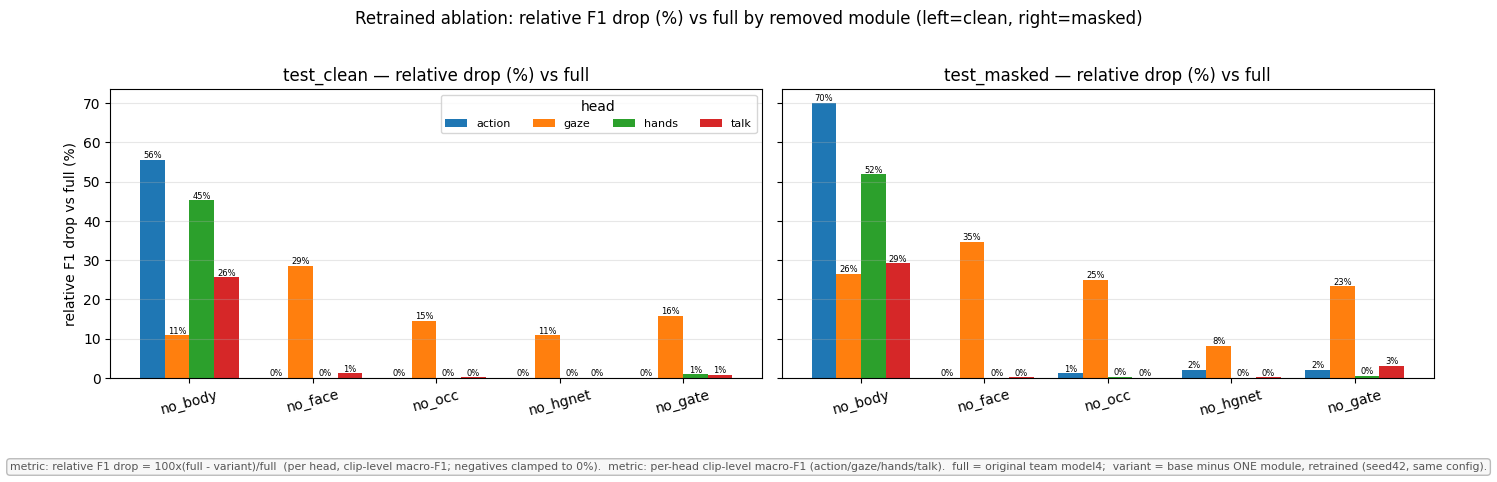

In [4]:
base=df[df["variant"]=="full"].iloc[0]
variants=[v for v in ORDER if v!="full" and v in df["variant"].values]
fig,axes=plt.subplots(1,2,figsize=(14,4.6),sharey=True)
for ax,sp in zip(axes,("test_clean","test_masked")):
    x=np.arange(len(variants)); w=0.2
    for i,h in enumerate(HEADS):
        vals=[max(0.0, 100*(base[f"{sp}_{h}"]-df[df["variant"]==v].iloc[0][f"{sp}_{h}"])/base[f"{sp}_{h}"]) if base[f"{sp}_{h}"]>0 else 0.0 for v in variants]  # full 대비 상대%, 음수→0
        b=ax.bar(x+i*w,vals,w,label=h); ax.bar_label(b,fmt="%.0f%%",fontsize=6)
    ax.set_xticks(x+1.5*w); ax.set_xticklabels(variants,rotation=15)
    ax.set_title(sp+" — relative drop (%) vs full"); ax.axhline(0,color="k",lw=0.6); ax.grid(axis="y",alpha=0.3)
axes[0].set_ylabel("relative F1 drop vs full (%)"); axes[0].legend(title="head",ncol=4,fontsize=8)
fig.suptitle("Retrained ablation: relative F1 drop (%) vs full by removed module (left=clean, right=masked)",y=1.02)
cap(fig, "metric: relative F1 drop = 100x(full - variant)/full  (per head, clip-level macro-F1; negatives clamped to 0%).  "+F1_DEF); plt.show()

**해석.** 왼쪽(clean) vs 오른쪽(masked) 대조가 핵심입니다.
- `no_body` → action/hands 큰 drop (신체 지배)
- `no_face` → gaze 큰 drop (시선=얼굴)
- `no_hgnet`/`no_occ`/`no_gate` → **masked 에서 clean 보다 drop 이 커지면** 차폐 처리 모듈이 worst case 에서 기여.

## 5. 절대 F1 막대 (변형별, masked=worst case)

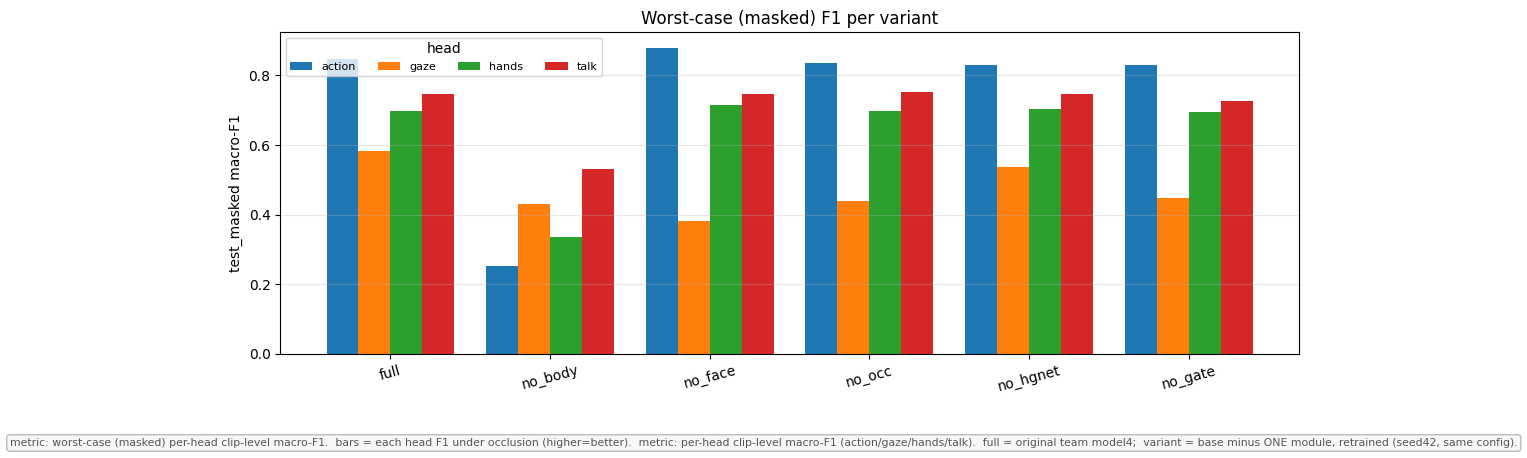

saved /data/shared/scuppy/Full_System/experiments/retrain_ablation/retrain_ablation_f1.csv


In [5]:
fig,ax=plt.subplots(figsize=(11,4.6))
present=[v for v in ORDER if v in df["variant"].values]
x=np.arange(len(present)); w=0.2
for i,h in enumerate(HEADS):
    vals=[df[df["variant"]==v].iloc[0][f"test_masked_{h}"] for v in present]
    ax.bar(x+i*w,vals,w,label=h)
ax.set_xticks(x+1.5*w); ax.set_xticklabels(present,rotation=15)
ax.set_ylabel("test_masked macro-F1"); ax.set_title("Worst-case (masked) F1 per variant")
ax.legend(title="head",ncol=4,fontsize=8); ax.grid(axis="y",alpha=0.3)
cap(fig, "metric: worst-case (masked) per-head clip-level macro-F1.  bars = each head F1 under occlusion (higher=better).  "+F1_DEF); plt.show()

SAVE=Path("/data/shared/scuppy/Full_System/experiments/retrain_ablation")
df.round(4).to_csv(SAVE/"retrain_ablation_f1.csv",index=False)
print("saved", SAVE/"retrain_ablation_f1.csv")

**해석 / 결론.** 재학습 기반이므로 이 F1 drop 이 **각 모듈의 진짜 기여도**입니다
(입력 zero/agreement 대용지표와 달리, 모듈 없이 새로 학습한 모델의 실제 성능).
`full` 이 모든(또는 worst-case) 지표에서 가장 높고, 각 모듈 제거 시 해당 task 가 떨어지면 그 모듈이 필요하다는 직접 증거입니다.